# Phase 8 — 정답(GT) 파싱과 정량 평가 (실무 방식 재구성)

정답지: `src/perceptrack3d/evaluation/{tracklets.py, metrics.py, evaluate.py}`, `scripts/check_tracklets.py`, `docs/learning_notes/phase8_ground_truth.md`, `phase8_evaluation.md`, `outputs/phase8/results.md`.

목표는 같다 — KITTI raw 의 `tracklet_labels.xml` 을 읽어 프레임별 3D 정답 박스를 만들고, 변형 A(raw 융합) / B(클러스터 융합) / C(추적) 의 3D 결과를 **BEV 중심 거리 2 m** 로 매칭해 재현율·정밀도·오차·IoU·IDSW 표를 만드는 것.
여기서는 실무자가 하듯 **검색해서 가져다 붙인다**: XML 파서는 KITTI 사이트가 배포하는 `parseTrackletXML.py`(2012, Python 2!), 박스 모서리는 devkit MATLAB 데모, 매칭 규칙은 nuScenes devkit, 지표 정의는 CLEAR MOT 논문 + py-motmetrics, 회전 박스 IoU 는 shapely.

| 조각 | 출처 | 라이선스 | 왜 |
|---|---|---|---|
| 1. `tracklet_labels.xml` 파싱 | KITTI raw 페이지 배포 `parseTrackletXML.py` (C. Herdtweck, MPI) + devkit `readme.txt` tracklet 절 + `cpp/tracklets.h` enum | KITTI 배포 스크립트 (라이선스 명시 없음, 연구용) / KITTI devkit | boost serialization XML 을 손으로 뒤지지 않는다. state/occlusion/truncation 상수의 근거 |
| 2. 3D 박스 모서리 → 중심·BEV | devkit `matlab/run_demoTracklets.m` + `wrapToPi.m` | KITTI devkit | "tz 는 바닥 중심, l 은 진행 방향" 을 코드로 확인. numpy 로 포팅 |
| 3. 중심 거리 매칭 | nuscenes-devkit `eval/common/utils.py::center_distance`, `eval/detection/algo.py::accumulate`, `detection_cvpr_2019.json` | Apache-2.0 | IoU 대신 BEV 중심 거리 임계값 {0.5, 1, 2, 4} m 로 매칭하는 업계 규칙 |
| 4. 정밀도·재현율·MOTA·IDSW | Bernardin & Stiefelhagen 2008 (CLEAR MOT, DOI 10.1155/2008/246309) + py-motmetrics `metrics.py`, `mot.py` | 논문(open access) / MIT | 지표 정의 문장과 구현 한 줄을 대조 |
| 5. 회전 박스 BEV IoU | shapely 매뉴얼 `Polygon`, `.intersection()`, `.area` | 문서 CC BY 3.0 US / 라이브러리 BSD-3 | 실무 표준 라이브러리로 IoU. 정답지의 Sutherland–Hodgman 직접 구현과 비교 |

좌표계: 모든 3D 값은 **Velodyne** (x 전방, y 좌, z 상, m). "BEV 거리" 는 (x, y) 평면 유클리드 거리, "깊이" 는 x.

In [1]:
import json, math, collections, warnings, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from perceptrack3d.config import load_config
from perceptrack3d.fusion.frustum_fusion import load_objects_json   # 입력 데이터(융합 결과 JSON) 읽기 전용 — 지시서에서 허용

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
np.random.seed(0)
rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True, linewidth=140)
pd.set_option("display.width", 160)

cfg = load_config()                                     # 경로·파라미터는 여기서만
OUT = Path(cfg["outputs"]["dir"])
GT_XML = cfg["dataset"]["tracklets"]
VELO_DIR = Path(cfg["dataset"]["velo_dir"]); FID_W = cfg["dataset"]["frame_id_width"]
TAU = float(cfg["evaluation"]["match_distance_m"]); CLASSES = list(cfg["evaluation"]["classes"]); X_MAX = float(cfg["fusion"]["roi"]["x_max"])

objects_A = load_objects_json(OUT / "phase5/objects_raw.json")          # 변형 A: 2D 박스 + raw LiDAR 통계
objects_B = load_objects_json(OUT / "phase6/objects_clustered.json")    # 변형 B: 2D 박스 + 필터/클러스터 LiDAR
tracks_C = {int(k): v for k, v in json.load(open(OUT / "phase7/tracks.json")).items()}   # 변형 C: B + 칼만 추적 (confirmed 트랙)

def load_points(frame_id):
    """Velodyne .bin → (N, 4) float32 [x, y, z, reflectance] (01 노트북과 같은 방법)."""
    return np.fromfile(VELO_DIR / f"{frame_id:0{FID_W}d}.bin", dtype=np.float32).reshape(-1, 4)

print(f"GT XML: {GT_XML}")
print(f"A {len(objects_A)} 프레임, B {len(objects_B)} 프레임, C {len(tracks_C)} 프레임 | τ = {TAU} m, 클래스 {CLASSES}, x ≤ {X_MAX} m")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


GT XML: /home/ingon/datasets/KITTI/raw/2011_09_26/2011_09_26_drive_0015_sync/tracklet_labels.xml
A 297 프레임, B 297 프레임, C 297 프레임 | τ = 2.0 m, 클래스 ['Car', 'Van', 'Truck', 'Pedestrian', 'Cyclist'], x ≤ 70.0 m


### 조각 1. `tracklet_labels.xml` 파싱 — KITTI 가 배포하는 `parseTrackletXML.py`

- **검색어**: `kitti tracklet_labels.xml python parser`, `kitti raw data parseTrackletXML`
- **출처**:
  - `parseTrackletXML.py` — https://www.cvlibs.net/datasets/kitti/raw_data.php 의 "downloads/parseTrackletXML.py" (Christian Herdtweck, Max Planck Institute for Biological Cybernetics, 2012–2014) — 라이선스 명시 없음 ("No guarantees that this code is correct, usage is at your own risk!"), KITTI 사이트 배포 연구용 스크립트 — 2026-09-08 — `notebooks_2nd/sources/kitti_parseTrackletXML/parseTrackletXML.py`
  - KITTI raw devkit `readme.txt` "Tracklet Labels" 절, `cpp/tracklets.h` — https://s3.eu-central-1.amazonaws.com/avg-kitti/devkit_raw_data.zip — 2026-09-08 — `notebooks_2nd/sources/kitti_devkit/devkit/`
- **왜 이걸 가져오나**: XML 은 C++ boost serialization 이 뱉은 형식이라 태그가 `<item>` 투성이다. 이미 검증된 파서를 쓰고, 상수(state/occlusion/truncation) 의 근거는 `tracklets.h` 의 enum 에서 확인한다.
- **읽을 때 볼 곳**: `readme.txt` — "**All tracklets are represented in Velodyne coordinates.**" 한 문장. `tracklets.h` — `enum POSE_STATES / OCCLUSION_STATES / TRUNCATION_STATES`, `struct tPose { double tx,ty,tz; // translation wrt. Velodyne coordinates ...}`, `getPose()` 의 `pose_idx = frame_number - first_frame`. `parseTrackletXML.py` — `class Tracklet` 의 필드 설명 (`size = (height, width, length)` 순서!), `parseXML()`.
- **실제로 터지는 곳**: 이 스크립트는 **Python 2** 다 (`print 'x'`, `itertools.izip`, `xrange`). 그대로 붙이면 `SyntaxError`. 아래 A 셀은 원문에 py2→py3 최소 수정 7줄만 `# CHANGED` 로 표시했다.

`readme.txt` (원문):
```text
Tracklet Labels
===============

Tracklet labels are stored in XML and can be read / written using the 
C++/MATLAB source code provided with this development kit. For compiling
the code you will need to have a recent version of the boost libraries
installed.

Each tracklet is stored as a 3D bounding box of given height, width and
length, spanning multiple frames. For each frame we have labeled 3D location
and rotation in bird's eye view. Additionally, occlusion / truncation 
information is provided in the form of averaged Mechanical Turk label
outputs. All tracklets are represented in Velodyne coordinates.

Object categories are classified as following:

  - 'Car'
  - 'Van'
  - 'Truck'
  - 'Pedestrian'
  - 'Person (sitting)'
  - 'Cyclist'
  - 'Tram'
  - 'Misc'

Here, 'Misc' denotes all other categories, e.g., 'Trailers' or 'Segways'.
```

`cpp/tracklets.h` (원문, enum 과 pose 구조체 일부):
```cpp
  // pose states
  enum POSE_STATES {
    UNSET   = 0,
    INTERP  = 1,
    LABELED = 2
  };

  // occlusion states
  enum OCCLUSION_STATES {
    OCCLUSION_UNSET = -1,
    VISIBLE         = 0,
    PARTLY          = 1,
    FULLY           = 2
  };

  // occlusion states
  enum TRUNCATION_STATES {
    TRUNCATION_UNSET  = -1,
    IN_IMAGE          = 0,
    TRUNCATED         = 1,
    OUT_IMAGE         = 2,
    BEHIND_IMAGE      = 99
  };

  struct tPose{

    double            tx,ty,tz;         // translation wrt. Velodyne coordinates
    double            rx,ry,rz;         // rotation wrt. Velodyne coordinates
  ...
  bool getPose (int tracklet_id, int frame_number,tPose* &pose) {
    if (!isActive(tracklet_id,frame_number)) {
      return false;
    } else {
      int pose_idx = frame_number-tracklets[tracklet_id].first_frame;
      pose = &(tracklets[tracklet_id].poses[pose_idx]);
      return true;
    }
  }
  
```

In [2]:
# ORIGINAL: kitti_parseTrackletXML/parseTrackletXML.py :: 상수, class Tracklet, parseXML (lines 30-268), KITTI raw data page 배포 (Christian Herdtweck, MPI Tübingen)
#           Python 2 코드라 7줄만 py3 로 고쳤다 (# CHANGED 표시). 나머지는 원문 그대로.
from xml.etree.ElementTree import ElementTree
import numpy as np
import itertools
from warnings import warn

STATE_UNSET = 0
STATE_INTERP = 1
STATE_LABELED = 2
stateFromText = {'0':STATE_UNSET, '1':STATE_INTERP, '2':STATE_LABELED}

OCC_UNSET = 255  # -1 as uint8
OCC_VISIBLE = 0
OCC_PARTLY = 1
OCC_FULLY = 2
occFromText = {'-1':OCC_UNSET, '0':OCC_VISIBLE, '1':OCC_PARTLY, '2':OCC_FULLY}

TRUNC_UNSET = 255  # -1 as uint8, but in xml files the value '99' is used!
TRUNC_IN_IMAGE = 0
TRUNC_TRUNCATED = 1
TRUNC_OUT_IMAGE = 2
TRUNC_BEHIND_IMAGE = 3
truncFromText = {'99':TRUNC_UNSET, '0':TRUNC_IN_IMAGE, '1':TRUNC_TRUNCATED, \
                  '2':TRUNC_OUT_IMAGE, '3': TRUNC_BEHIND_IMAGE}


class Tracklet(object):
  r""" representation an annotated object track 
  
  Tracklets are created in function parseXML and can most conveniently used as follows:

  for trackletObj in parseXML(trackletFile):
    for translation, rotation, state, occlusion, truncation, amtOcclusion, amtBorders, absoluteFrameNumber in trackletObj:
      ... your code here ...
    #end: for all frames
  #end: for all tracklets

  absoluteFrameNumber is in range [firstFrame, firstFrame+nFrames[
  amtOcclusion and amtBorders could be None

  You can of course also directly access the fields objType (string), size (len-3 ndarray), firstFrame/nFrames (int), 
    trans/rots (nFrames x 3 float ndarrays), states/truncs (len-nFrames uint8 ndarrays), occs (nFrames x 2 uint8 ndarray),
    and for some tracklets amtOccs (nFrames x 2 float ndarray) and amtBorders (nFrames x 3 float ndarray). The last two
    can be None if the xml file did not include these fields in poses
  """

  objectType = None
  size = None  # len-3 float array: (height, width, length)
  firstFrame = None
  trans = None   # n x 3 float array (x,y,z)
  rots = None    # n x 3 float array (x,y,z)
  states = None  # len-n uint8 array of states
  occs = None    # n x 2 uint8 array  (occlusion, occlusion_kf)
  truncs = None  # len-n uint8 array of truncation
  amtOccs = None    # None or (n x 2) float array  (amt_occlusion, amt_occlusion_kf)
  amtBorders = None    # None (n x 3) float array  (amt_border_l / _r / _kf)
  nFrames = None

  def __init__(self):
    r""" create Tracklet with no info set """
    self.size = np.nan*np.ones(3, dtype=float)

  def __str__(self):
    r""" return human-readable string representation of tracklet object

    called implicitly in 
    print trackletObj
    or in 
    text = str(trackletObj)
    """
    return '[Tracklet over {0} frames for {1}]'.format(self.nFrames, self.objectType)

  def __iter__(self):
    r""" returns an iterator that yields tuple of all the available data for each frame 
    
    called whenever code iterates over a tracklet object, e.g. in 
    for translation, rotation, state, occlusion, truncation, amtOcclusion, amtBorders, absoluteFrameNumber in trackletObj:
      ...do something ...
    or
    trackDataIter = iter(trackletObj)
    """
    if self.amtOccs is None:
      return zip(self.trans, self.rots, self.states, self.occs, self.truncs, \
          itertools.repeat(None), itertools.repeat(None), range(self.firstFrame, self.firstFrame+self.nFrames))   # CHANGED: py2→py3 (itertools.izip → zip, xrange → range)
    else:
      return zip(self.trans, self.rots, self.states, self.occs, self.truncs, \
          self.amtOccs, self.amtBorders, range(self.firstFrame, self.firstFrame+self.nFrames))   # CHANGED: py2→py3 (itertools.izip → zip, xrange → range)
#end: class Tracklet


def parseXML(trackletFile):
  r""" parse tracklet xml file and convert results to list of Tracklet objects
  
  :param trackletFile: name of a tracklet xml file
  :returns: list of Tracklet objects read from xml file
  """

  # convert tracklet XML data to a tree structure
  eTree = ElementTree()
  print('parsing tracklet file', trackletFile)   # CHANGED: py2→py3 print 문 → 함수
  with open(trackletFile) as f:
    eTree.parse(f)

  # now convert output to list of Tracklet objects
  trackletsElem = eTree.find('tracklets')
  tracklets = []
  trackletIdx = 0
  nTracklets = None
  for trackletElem in trackletsElem:
    #print 'track:', trackletElem.tag
    if trackletElem.tag == 'count':
      nTracklets = int(trackletElem.text)
      print('file contains', nTracklets, 'tracklets')   # CHANGED: py2→py3 print 문 → 함수
    elif trackletElem.tag == 'item_version':
      pass
    elif trackletElem.tag == 'item':
      #print 'tracklet {0} of {1}'.format(trackletIdx, nTracklets)
      # a tracklet
      newTrack = Tracklet()
      isFinished = False
      hasAmt = False
      frameIdx = None
      for info in trackletElem:
        #print 'trackInfo:', info.tag
        if isFinished:
          raise ValueError('more info on element after finished!')
        if info.tag == 'objectType':
          newTrack.objectType = info.text
        elif info.tag == 'h':
          newTrack.size[0] = float(info.text)
        elif info.tag == 'w':
          newTrack.size[1] = float(info.text)
        elif info.tag == 'l':
          newTrack.size[2] = float(info.text)
        elif info.tag == 'first_frame':
          newTrack.firstFrame = int(info.text)
        elif info.tag == 'poses':
          # this info is the possibly long list of poses
          for pose in info:
            #print 'trackInfoPose:', pose.tag
            if pose.tag == 'count':   # this should come before the others
              if newTrack.nFrames is not None:
                raise ValueError('there are several pose lists for a single track!')
              elif frameIdx is not None:
                raise ValueError('?!')
              newTrack.nFrames = int(pose.text)
              newTrack.trans  = np.nan * np.ones((newTrack.nFrames, 3), dtype=float)
              newTrack.rots   = np.nan * np.ones((newTrack.nFrames, 3), dtype=float)
              newTrack.states = np.nan * np.ones(newTrack.nFrames, dtype='uint8')
              newTrack.occs   = np.nan * np.ones((newTrack.nFrames, 2), dtype='uint8')
              newTrack.truncs = np.nan * np.ones(newTrack.nFrames, dtype='uint8')
              newTrack.amtOccs = np.nan * np.ones((newTrack.nFrames, 2), dtype=float)
              newTrack.amtBorders = np.nan * np.ones((newTrack.nFrames, 3), dtype=float)
              frameIdx = 0
            elif pose.tag == 'item_version':
              pass
            elif pose.tag == 'item':
              # pose in one frame
              if frameIdx is None:
                raise ValueError('pose item came before number of poses!')
              for poseInfo in pose:
                #print 'trackInfoPoseInfo:', poseInfo.tag
                if poseInfo.tag == 'tx':
                  newTrack.trans[frameIdx, 0] = float(poseInfo.text)
                elif poseInfo.tag == 'ty':
                  newTrack.trans[frameIdx, 1] = float(poseInfo.text)
                elif poseInfo.tag == 'tz':
                  newTrack.trans[frameIdx, 2] = float(poseInfo.text)
                elif poseInfo.tag == 'rx':
                  newTrack.rots[frameIdx, 0] = float(poseInfo.text)
                elif poseInfo.tag == 'ry':
                  newTrack.rots[frameIdx, 1] = float(poseInfo.text)
                elif poseInfo.tag == 'rz':
                  newTrack.rots[frameIdx, 2] = float(poseInfo.text)
                elif poseInfo.tag == 'state':
                  newTrack.states[frameIdx] = stateFromText[poseInfo.text]
                elif poseInfo.tag == 'occlusion':
                  newTrack.occs[frameIdx, 0] = occFromText[poseInfo.text]
                elif poseInfo.tag == 'occlusion_kf':
                  newTrack.occs[frameIdx, 1] = occFromText[poseInfo.text]
                elif poseInfo.tag == 'truncation':
                  newTrack.truncs[frameIdx] = truncFromText[poseInfo.text]
                elif poseInfo.tag == 'amt_occlusion':
                  newTrack.amtOccs[frameIdx,0] = float(poseInfo.text)
                  hasAmt = True
                elif poseInfo.tag == 'amt_occlusion_kf':
                  newTrack.amtOccs[frameIdx,1] = float(poseInfo.text)
                  hasAmt = True
                elif poseInfo.tag == 'amt_border_l':
                  newTrack.amtBorders[frameIdx,0] = float(poseInfo.text)
                  hasAmt = True
                elif poseInfo.tag == 'amt_border_r':
                  newTrack.amtBorders[frameIdx,1] = float(poseInfo.text)
                  hasAmt = True
                elif poseInfo.tag == 'amt_border_kf':
                  newTrack.amtBorders[frameIdx,2] = float(poseInfo.text)
                  hasAmt = True
                else:
                  raise ValueError('unexpected tag in poses item: {0}!'.format(poseInfo.tag))
              frameIdx += 1
            else:
              raise ValueError('unexpected pose info: {0}!'.format(pose.tag))
        elif info.tag == 'finished':
          isFinished = True
        else:
          raise ValueError('unexpected tag in tracklets: {0}!'.format(info.tag))
      #end: for all fields in current tracklet

      # some final consistency checks on new tracklet
      if not isFinished:
        warn('tracklet {0} was not finished!'.format(trackletIdx))
      if newTrack.nFrames is None:
        warn('tracklet {0} contains no information!'.format(trackletIdx))
      elif frameIdx != newTrack.nFrames:
        warn('tracklet {0} is supposed to have {1} frames, but perser found {1}!'.format(\
            trackletIdx, newTrack.nFrames, frameIdx))
      if np.abs(newTrack.rots[:,:2]).sum() > 1e-16:
        warn('track contains rotation other than yaw!')

      # if amtOccs / amtBorders are not set, set them to None
      if not hasAmt:
        newTrack.amtOccs = None
        newTrack.amtBorders = None

      # add new tracklet to list
      tracklets.append(newTrack)
      trackletIdx += 1

    else:
      raise ValueError('unexpected tracklet info')
  #end: for tracklet list items

  print('loaded', trackletIdx, 'tracklets')   # CHANGED: py2→py3 print 문 → 함수

  # final consistency check
  if trackletIdx != nTracklets:
    warn('according to xml information the file has {0} tracklets, but parser found {1}!'.format(nTracklets, trackletIdx))

  return tracklets
#end: function parseXML

print('parseXML 정의됨. 상수: STATE_*', (STATE_UNSET, STATE_INTERP, STATE_LABELED), 'OCC_*', (OCC_UNSET, OCC_VISIBLE, OCC_PARTLY, OCC_FULLY), 'TRUNC_*', (TRUNC_UNSET, TRUNC_IN_IMAGE, TRUNC_TRUNCATED, TRUNC_OUT_IMAGE, TRUNC_BEHIND_IMAGE))

parseXML 정의됨. 상수: STATE_* (0, 1, 2) OCC_* (255, 0, 1, 2) TRUNC_* (255, 0, 1, 2, 3)


In [3]:
# 우리 데이터에 적용
tracklets = parseXML(GT_XML)
types = collections.Counter(t.objectType for t in tracklets)
print(f"\ntracklet {len(tracklets)}개, 타입 집계 {dict(types)}")
t0 = tracklets[0]
print("첫 tracklet:", t0, "| size (h, w, l) =", t0.size, "| firstFrame", t0.firstFrame, "nFrames", t0.nFrames)
print("  trans[0] (tx, ty, tz) =", t0.trans[0], " rots[0] (rx, ry, rz) =", t0.rots[0], " states[:3] =", t0.states[:3], "(dtype", t0.states.dtype, ")")
all_states = set(np.concatenate([t.states for t in tracklets]).astype(int).tolist())
all_occ = set(np.concatenate([t.occs[:, 0] for t in tracklets]).astype(int).tolist())
all_trunc = set(np.concatenate([t.truncs for t in tracklets]).astype(int).tolist())
print(f"  값 집합: state {sorted(all_states)} (1 INTERP, 2 LABELED), occlusion {sorted(all_occ)}, truncation {sorted(all_trunc)}")
print("  주의: 파서는 XML 의 truncation '99' 를 TRUNC_UNSET(255) 로 매핑하지만 tracklets.h 는 BEHIND_IMAGE = 99 다 — 두 공식 자료가 다르다. 값 255 는 '99 였던 것' 으로 읽는다.")

# __iter__ 로 프레임별 pose 전개: absoluteFrameNumber = firstFrame + i (tracklets.h getPose 와 같은 규칙)
n_pose = 0; per_frame = collections.Counter()
for tr in tracklets:
    for translation, rotation, state, occlusion, truncation, amtOcclusion, amtBorders, absoluteFrameNumber in tr:
        n_pose += 1; per_frame[absoluteFrameNumber] += 1
print(f"  pose 총 {n_pose}개, 프레임 {min(per_frame)}~{max(per_frame)}, 프레임당 GT min {min(per_frame.values())} / mean {np.mean(list(per_frame.values())):.2f} / max {max(per_frame.values())}")
pd.DataFrame([{"id": i, "type": t.objectType, "first": t.firstFrame, "n": t.nFrames, "last": t.firstFrame + t.nFrames - 1,
               "h": t.size[0], "w": t.size[1], "l": t.size[2], "x0": t.trans[0, 0], "y0": t.trans[0, 1], "z0(tz)": t.trans[0, 2]} for i, t in enumerate(tracklets)]).head(8)

parsing tracklet file /home/ingon/datasets/KITTI/raw/2011_09_26/2011_09_26_drive_0015_sync/tracklet_labels.xml
file contains 36 tracklets
loaded 36 tracklets

tracklet 36개, 타입 집계 {'Car': 33, 'Van': 1, 'Truck': 1, 'Cyclist': 1}
첫 tracklet: [Tracklet over 15 frames for Car] | size (h, w, l) = [1.716 1.628 3.542] | firstFrame 0 nFrames 15
  trans[0] (tx, ty, tz) = [46.781 21.213 -1.263]  rots[0] (rx, ry, rz) = [ 0.     0.    -0.032]  states[:3] = [2. 1. 1.] (dtype float64 )
  값 집합: state [1, 2] (1 INTERP, 2 LABELED), occlusion [0, 1, 2], truncation [0, 1, 2, 255]
  주의: 파서는 XML 의 truncation '99' 를 TRUNC_UNSET(255) 로 매핑하지만 tracklets.h 는 BEHIND_IMAGE = 99 다 — 두 공식 자료가 다르다. 값 255 는 '99 였던 것' 으로 읽는다.
  pose 총 1477개, 프레임 0~296, 프레임당 GT min 1 / mean 4.97 / max 11


,id,type,first,n,last,h,w,l,x0,y0,z0(tz)
0,0,Car,0,15,14,1.716012,1.628068,3.541835,46.781215,21.213167,-1.262537
1,1,Car,0,20,19,1.520720,1.503656,3.508354,57.857873,21.497415,-1.029608
2,2,Car,10,29,38,1.471469,1.824792,3.025945,71.008704,21.892880,-1.031024
3,3,Car,28,35,62,1.421482,1.679709,3.928553,71.577169,23.131676,-0.551133
4,4,Car,26,32,57,2.481779,1.809764,4.733708,76.104597,29.202879,-0.321150
5,5,Car,44,23,66,1.636105,1.831630,3.654223,52.221307,22.341342,-0.875018
6,6,Car,53,47,99,1.548727,1.367971,3.967421,71.852266,22.537912,-0.789336
7,7,Car,55,54,108,1.690713,1.735219,3.760390,77.323348,22.804061,-0.540547


In [4]:
# 검증: 정답지 load_tracklets (표준 ElementTree 직접 파싱) 와 같은 내용인가
from perceptrack3d.evaluation.tracklets import load_tracklets

ref = load_tracklets(GT_XML)
ok_count = len(ref) == len(tracklets)
ok_meta = all(r["object_type"] == t.objectType and r["first_frame"] == t.firstFrame and len(r["poses"]) == t.nFrames
              and np.allclose([r["h"], r["w"], r["l"]], t.size) for r, t in zip(ref, tracklets))
ok_pose = all(np.allclose(np.array([[p["tx"], p["ty"], p["tz"]] for p in r["poses"]]), t.trans)
              and np.allclose(np.array([p["rz"] for p in r["poses"]]), t.rots[:, 2]) for r, t in zip(ref, tracklets))
ok_state = all(np.array_equal(np.array([p["state"] for p in r["poses"]]), t.states.astype(int)) for r, t in zip(ref, tracklets))
print(f"tracklet 수 {ok_count}, 타입/first_frame/pose 수/h,w,l {ok_meta}, tx,ty,tz,rz {ok_pose}, state {ok_state}")
assert ok_count and ok_meta and ok_pose and ok_state
# occlusion / truncation 은 정답지가 원값(-1, 99) 을 그대로 두고, 파서는 255 로 바꾼다 → 매핑해서 비교
trunc_ref = np.concatenate([[p["truncation"] for p in r["poses"]] for r in ref]); trunc_py = np.concatenate([t.truncs for t in tracklets]).astype(int)
print("truncation: 정답지 원값 집합", sorted(set(trunc_ref.tolist())), "↔ 파서", sorted(set(trunc_py.tolist())), "| 99↔255 로 매핑하면 일치:", np.array_equal(np.where(trunc_ref == 99, 255, trunc_ref), trunc_py))

tracklet 수 True, 타입/first_frame/pose 수/h,w,l True, tx,ty,tz,rz True, state True
truncation: 정답지 원값 집합 [0, 1, 2, 99] ↔ 파서 [0, 1, 2, 255] | 99↔255 로 매핑하면 일치: True


### 조각 2. devkit `run_demoTracklets.m` 의 3D 박스 모서리 → numpy 포팅 — "tz 는 바닥 중심"

- **검색어**: `kitti tracklet 3d bounding box corners velodyne`, `kitti devkit run_demoTracklets`
- **출처**: KITTI raw devkit `matlab/run_demoTracklets.m`, `matlab/wrapToPi.m` — https://www.cvlibs.net/datasets/kitti/raw_data.php ("raw data development kit") — KITTI — 2026-09-08 — `notebooks_2nd/sources/kitti_devkit/devkit/matlab/`
- **왜 이걸 가져오나**: XML 의 (tx, ty, tz) 가 박스의 어디인지, (h, w, l) 이 어느 축인지, rz 의 부호가 어느 방향인지는 문서에 없고 **데모 코드에만** 있다. 모서리 z 가 `[0,0,0,0,h,h,h,h]` 이므로 tz 는 **바닥** 이고, x = ±l/2 (front/back), y = ±w/2 (left/right) 이므로 l 은 진행 방향이다. 우리 융합 결과는 기하 중심이므로 GT 중심 = tz + h/2 로 올려야 비교가 된다.
- **읽을 때 볼 곳**: `corners(it).x/y/z` 세 줄, `R = [cos -sin 0; sin cos 0; 0 0 1]`, `corners_3D = R*[...]` 뒤에 `t` 를 더하는 세 줄, `pose_idx = img_idx-first_frame+1` (MATLAB 1-based). **함정**: 위쪽 주석 "LOCAL OBJECT COORDINATE SYSTEM: x -> facing right, y -> facing forward" 는 코드와 다르다 — 코드는 x 가 front/back 이다. 주석이 아니라 코드를 따른다.

`run_demoTracklets.m` (원문 발췌):
```matlab
% extract tracklets
% LOCAL OBJECT COORDINATE SYSTEM:
%   x -> facing right
%   y -> facing forward
%   z -> facing up
for it = 1:numel(tracklets)
  
  % shortcut for tracklet dimensions
  w = tracklets{it}.w;
  h = tracklets{it}.h;
  l = tracklets{it}.l;

  % set bounding box corners
  corners(it).x = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]; % front/back
  corners(it).y = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]; % left/right
  corners(it).z = [0,0,0,0,h,h,h,h];
  
  % get translation and orientation
  t{it} = [tracklets{it}.poses(1,:); tracklets{it}.poses(2,:); tracklets{it}.poses(3,:)];
  rz{it} = wrapToPi(tracklets{it}.poses(6,:));
  occlusion{it} = tracklets{it}.poses(8,:);
  ...
  
  % compute bounding boxes for visible tracklets
  for it = 1:numel(tracklets)
    
    % get relative tracklet frame index (starting at 0 with first appearance; 
    % xml data stores poses relative to the first frame where the tracklet appeared)
    pose_idx = img_idx-tracklets{it}.first_frame+1; % 0-based => 1-based MATLAB index

    % only draw tracklets that are visible in current frame
    if pose_idx<1 || pose_idx>(size(tracklets{it}.poses,2))
      continue;
    end

    % compute 3d object rotation in velodyne coordinates
    % VELODYNE COORDINATE SYSTEM:
    %   x -> facing forward
    %   y -> facing left
    %   z -> facing up
    R = [cos(rz{it}(pose_idx)), -sin(rz{it}(pose_idx)), 0;
         sin(rz{it}(pose_idx)),  cos(rz{it}(pose_idx)), 0;
                             0,                      0, 1];

    % rotate and translate 3D bounding box in velodyne coordinate system
    corners_3D      = R*[corners(it).x;corners(it).y;corners(it).z];
    corners_3D(1,:) = corners_3D(1,:) + t{it}(1,pose_idx);
    corners_3D(2,:) = corners_3D(2,:) + t{it}(2,pose_idx);
    corners_3D(3,:) = corners_3D(3,:) + t{it}(3,pose_idx);
    corners_3D      = (veloToCam{cam+1}*[corners_3D; ones(1,size(corners_3D,2))]);
```

`wrapToPi.m` (원문):
```matlab
function alpha = wrapToPi(alpha)

% wrap to [0..2*pi]
alpha = mod(alpha,2*pi);

% wrap to [-pi..pi]
idx = alpha>pi;
alpha(idx) = alpha(idx)-2*pi;
```

In [5]:
# PORTED FROM kitti_devkit/devkit/matlab/run_demoTracklets.m (lines 80-89, 110, 121-130) + wrapToPi.m — numpy 로 옮김
def wrapToPi(alpha):
    # wrap to [0..2*pi]
    alpha = np.mod(alpha, 2 * np.pi)
    # wrap to [-pi..pi]
    alpha = np.where(alpha > np.pi, alpha - 2 * np.pi, alpha)
    return alpha

def tracklet_corners_3d(h, w, l, t, rz):
    """MATLAB 의 corners(it) → R → +t 를 그대로. 반환 (3, 8): 행 = x, y, z (Velodyne), 열 = 모서리 (앞좌, 앞우, 뒤우, 뒤좌) × (바닥 4, 천장 4)."""
    # set bounding box corners
    corners_x = np.array([l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2])   # front/back
    corners_y = np.array([w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2])   # left/right
    corners_z = np.array([0, 0, 0, 0, h, h, h, h])
    # compute 3d object rotation in velodyne coordinates
    R = np.array([[np.cos(rz), -np.sin(rz), 0],
                  [np.sin(rz),  np.cos(rz), 0],
                  [         0,           0, 1]])
    # rotate and translate 3D bounding box in velodyne coordinate system
    corners_3D = R @ np.vstack([corners_x, corners_y, corners_z])
    corners_3D = corners_3D + np.asarray(t, dtype=float).reshape(3, 1)      # corners_3D(k,:) + t(k, pose_idx)
    return corners_3D

def gt_boxes_at(tracklets, frame):
    """프레임 frame 에 존재하는 GT 박스 목록. pose_idx = frame - first_frame (tracklets.h getPose; MATLAB 은 +1 로 1-based)."""
    boxes = []
    for tid, tr in enumerate(tracklets):
        pose_idx = frame - tr.firstFrame
        if pose_idx < 0 or pose_idx >= tr.nFrames:      # only draw tracklets that are visible in current frame
            continue
        h, w, l = tr.size                                # parseTrackletXML: size = (height, width, length)
        t = tr.trans[pose_idx]; rz = float(wrapToPi(tr.rots[pose_idx, 2]))
        boxes.append({"tracklet_id": tid, "type": tr.objectType, "t": t, "rz": rz, "h": h, "w": w, "l": l,
                      "corners": tracklet_corners_3d(h, w, l, t, rz),
                      "center": t + np.array([0.0, 0.0, h / 2]),   # 모서리 z ∈ [0, h] 이므로 t 는 바닥 중심 → 기하 중심 = t + h/2 (우리 융합 결과와 같은 기준)
                      "size": np.array([l, w, h]),                  # [l, w, h] = Velodyne x, y, z 방향 길이 (yaw 회전 전)
                      "occlusion": int(tr.occs[pose_idx, 0]), "truncation": int(tr.truncs[pose_idx]), "state": int(tr.states[pose_idx])})
    return boxes

b = gt_boxes_at(tracklets, 0)[0]
print("프레임 0, tracklet 0:", b["type"], "t =", b["t"], "rz =", round(b["rz"], 3), "h,w,l =", tuple(round(float(v), 2) for v in (b["h"], b["w"], b["l"])))
print("모서리 (3, 8) =\n", b["corners"])
print("→ z 행이 [tz ×4, tz+h ×4]: tz 는 바닥. 기하 중심 =", b["center"])

프레임 0, tracklet 0: Car t = [46.781 21.213 -1.263] rz = -0.032 h,w,l = (1.72, 1.63, 3.54)
모서리 (3, 8) =
 [[48.577 48.525 44.985 45.037 48.577 48.525 44.985 45.037]
 [21.97  20.343 20.456 22.083 21.97  20.343 20.456 22.083]
 [-1.263 -1.263 -1.263 -1.263  0.453  0.453  0.453  0.453]]
→ z 행이 [tz ×4, tz+h ×4]: tz 는 바닥. 기하 중심 = [46.781 21.213 -0.405]


frame 150: GT 5개, LiDAR 점 122757
 id type           x       y z(center)     l     w     h    yaw   pts
 11 Van        52.39    6.22      0.08  6.86  2.22  2.84  -3.09    52
 15 Car        58.67  -20.60     -1.32  4.26  1.39  1.68   1.70     2
 31 Car        21.74    0.88     -0.72  4.50  1.63  1.62   0.01   183
 32 Car        55.49   23.39     -0.35  4.15  1.31  1.46   3.13     8
 34 Cyclist    36.19   -9.80     -0.94  1.57  0.34  1.64   0.02    10



프레임 0..290 (10 간격) GT 박스 안 LiDAR 점 수 합계: {'A. tz = 바닥 (채택)': 30591, 'B. tz = 기하 중심': 23270, 'C. tz = 천장': 3498}


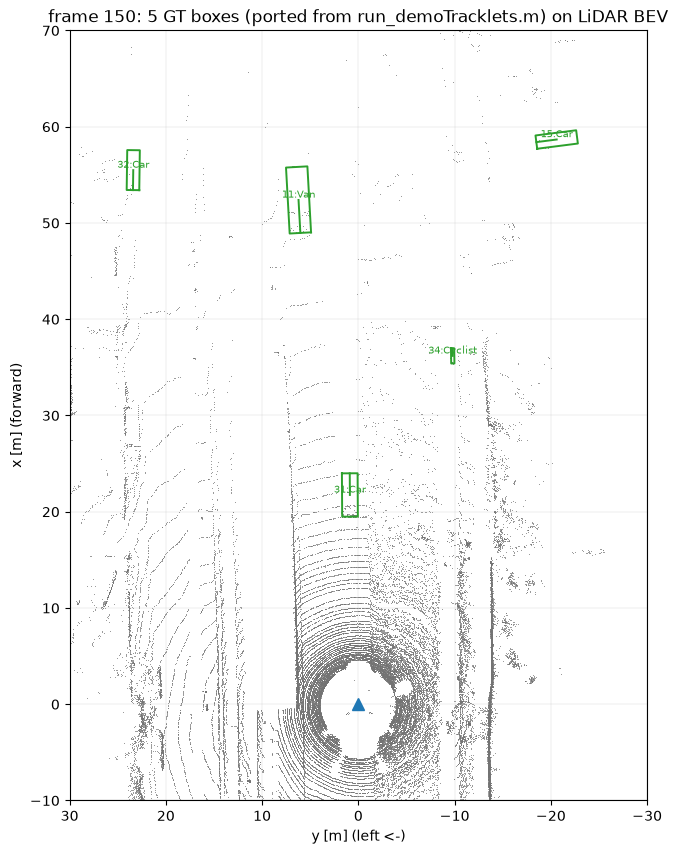

In [6]:
# 우리 데이터에 적용: 전 프레임 GT 사전 + 프레임 150 BEV (정답지 scripts/check_tracklets.py 재현) + 바닥/중심 가설 검증
GT = {f: gt_boxes_at(tracklets, f) for f in range(len(tracks_C))}

def points_in_box(pts, box):
    """회전 박스 안 점 mask. 점을 박스 로컬 프레임으로 되돌림: d = Rz(-rz)(p − t), |dx| ≤ l/2, |dy| ≤ w/2, 0 ≤ dz ≤ h (모서리 z 가 [0, h] 이므로)."""
    d = pts[:, :3].astype(float) - box["t"]
    c, s = np.cos(-box["rz"]), np.sin(-box["rz"])
    dx, dy = c * d[:, 0] - s * d[:, 1], s * d[:, 0] + c * d[:, 1]
    return (np.abs(dx) <= box["l"] / 2) & (np.abs(dy) <= box["w"] / 2) & (d[:, 2] >= 0) & (d[:, 2] <= box["h"])

F = 150
pts = load_points(F)
print(f"frame {F}: GT {len(GT[F])}개, LiDAR 점 {len(pts)}")
print(f"{'id':>3} {'type':<8} {'x':>7} {'y':>7} {'z(center)':>9} {'l':>5} {'w':>5} {'h':>5} {'yaw':>6} {'pts':>5}")
for b in GT[F]:
    n = int(points_in_box(pts, b).sum()); c = b["center"]
    print(f"{b['tracklet_id']:>3} {b['type']:<8} {c[0]:7.2f} {c[1]:7.2f} {c[2]:9.2f} {b['l']:5.2f} {b['w']:5.2f} {b['h']:5.2f} {b['rz']:6.2f} {n:5d}")

# 가설 검증 (정답지 학습노트 §2 와 같은 방법): 프레임 0..290 (10 간격) 의 모든 GT 박스 안 점 수 합계. tz 가 바닥이면 최대여야 한다
tot = {"A. tz = 바닥 (채택)": 0, "B. tz = 기하 중심": 0, "C. tz = 천장": 0}
for f in range(0, 291, 10):
    p = load_points(f)
    for b in GT[f]:
        for name, dz in (("A. tz = 바닥 (채택)", 0.0), ("B. tz = 기하 중심", -b["h"] / 2), ("C. tz = 천장", -b["h"])):
            bb = dict(b); bb["t"] = b["t"] + np.array([0, 0, dz])
            tot[name] += int(points_in_box(p, bb).sum())
print("\n프레임 0..290 (10 간격) GT 박스 안 LiDAR 점 수 합계:", tot)

fig, ax = plt.subplots(figsize=(9, 10))
sub = pts[rng.choice(len(pts), 60000, replace=False)]
ax.scatter(sub[:, 1], sub[:, 0], s=0.3, c="0.45", linewidths=0, rasterized=True)
for b in GT[F]:
    c4 = b["corners"][:2, :4]; closed = np.hstack([c4, c4[:, :1]])
    ax.plot(closed[1], closed[0], color="tab:green", lw=1.4)
    front_mid = c4[:, :2].mean(axis=1); ax.plot([b["center"][1], front_mid[1]], [b["center"][0], front_mid[0]], color="tab:green", lw=1.4)
    ax.text(b["center"][1], b["center"][0], f"{b['tracklet_id']}:{b['type']}", color="tab:green", fontsize=7, ha="center", va="bottom")
ax.plot(0, 0, "^", color="tab:blue", ms=9); ax.set_xlim(30, -30); ax.set_ylim(-10, 70); ax.set_aspect("equal"); ax.grid(True, lw=0.3, alpha=0.5)
ax.set_xlabel("y [m] (left <-)"); ax.set_ylabel("x [m] (forward)"); ax.set_title(f"frame {F}: {len(GT[F])} GT boxes (ported from run_demoTracklets.m) on LiDAR BEV"); plt.show()

In [7]:
# 검증: 정답지 gt_boxes_by_frame / box_corners_bev / points_in_box_mask 와 같은가 (프레임 150 + 전체 프레임 중심)
from perceptrack3d.evaluation.tracklets import gt_boxes_by_frame, box_corners_bev, points_in_box_mask

gts_ref = gt_boxes_by_frame(GT_XML)
ref150 = gts_ref[F]
ok_n = len(ref150) == len(GT[F])
ok_center = all(np.allclose(r.center, b["center"]) and np.allclose(r.size, b["size"]) and np.isclose(r.yaw, b["rz"]) and r.tracklet_id == b["tracklet_id"] for r, b in zip(ref150, GT[F]))
ok_corners = all(np.allclose(box_corners_bev(r.center, r.size, r.yaw), b["corners"][:2, :4].T) for r, b in zip(ref150, GT[F]))
ok_pts = all(int(points_in_box_mask(pts, r.center, r.size, r.yaw).sum()) == int(points_in_box(pts, b).sum()) for r, b in zip(ref150, GT[F]))
n_all = sum(len(v) for v in gts_ref.values()); ok_all = all(np.allclose(r.center, b["center"]) for f in gts_ref for r, b in zip(gts_ref[f], GT[f]))
print(f"frame {F}: 박스 수 {ok_n}, center/size/yaw/id {ok_center}, BEV 모서리 순서·값 {ok_corners}, 박스 안 점 수 {ok_pts}; 전 프레임 {n_all}개 박스 중심 allclose {ok_all}")
assert ok_n and ok_center and ok_corners and ok_pts and ok_all
print("→ 정답지 규약 (center = tz + h/2, size = [l, w, h], yaw = wrap(rz), 모서리 순서 앞좌·앞우·뒤우·뒤좌) 는 devkit 데모 코드에서 그대로 나온다")

frame 150: 박스 수 True, center/size/yaw/id True, BEV 모서리 순서·값 True, 박스 안 점 수 True; 전 프레임 1477개 박스 중심 allclose True
→ 정답지 규약 (center = tz + h/2, size = [l, w, h], yaw = wrap(rz), 모서리 순서 앞좌·앞우·뒤우·뒤좌) 는 devkit 데모 코드에서 그대로 나온다


### 조각 3. nuScenes 의 중심 거리 매칭 — 탐욕(신뢰도 순) 원문을 헝가리안 1:1 로 바꾸기

- **검색어**: `nuscenes detection evaluation center distance matching`, `nuscenes devkit accumulate dist_th`
- **출처**: nuscenes-devkit — https://github.com/nutonomy/nuscenes-devkit — Apache-2.0 (Copyright 2021 Motional) — 2026-09-08 — `python-sdk/nuscenes/eval/common/utils.py` (`center_distance`), `python-sdk/nuscenes/eval/detection/algo.py` (`accumulate`), `python-sdk/nuscenes/eval/detection/configs/detection_cvpr_2019.json` → `notebooks_2nd/sources/nuscenes_devkit/`
- **왜 이걸 가져오나**: 우리 박스는 크기 추정이 약해(표면만 보임) IoU 매칭이 불공정하다. nuScenes 검출 벤치마크는 IoU 대신 **BEV 중심 거리** `dist_ths = [0.5, 1.0, 2.0, 4.0]` m 로 매칭한다 (`dist_th_tp = 2.0`). 이 규칙을 빌린다.
- **읽을 때 볼 곳**: `center_distance` — `np.linalg.norm(pred.translation[:2] - gt.translation[:2])` (xy only). `accumulate` — 예측을 **신뢰도 내림차순**으로 돌며 아직 `taken` 되지 않은 GT 중 가장 가까운 것을 잡고 `min_dist < dist_th` 면 TP (탐욕 매칭). 우리 A/B/C 는 신뢰도 순서가 다 다르므로(C 는 신뢰도 없음) 프레임 안에서 **총거리 최소 1:1 (헝가리안)** 으로 바꾼다 (`# CHANGED`). 임계값 처리 `<` (nuScenes) vs `<=` (우리) 도 표시.

`eval/detection/algo.py :: accumulate()` 매칭 루프 (원문):
```python
    taken = set()  # Initially no gt bounding box is matched.
    for ind in sortind:
        pred_box = pred_boxes_list[ind]
        min_dist = np.inf
        match_gt_idx = None

        for gt_idx, gt_box in enumerate(gt_boxes[pred_box.sample_token]):

            # Find closest match among ground truth boxes
            if gt_box.detection_name == class_name and not (pred_box.sample_token, gt_idx) in taken:
                this_distance = dist_fcn(gt_box, pred_box)
                if this_distance < min_dist:
                    min_dist = this_distance
                    match_gt_idx = gt_idx

        # If the closest match is close enough according to threshold we have a match!
        is_match = min_dist < dist_th

        if is_match:
            taken.add((pred_box.sample_token, match_gt_idx))

            #  Update tp, fp and confs.
            tp.append(1)
            fp.append(0)
            conf.append(pred_box.detection_score)

            # Since it is a match, update match data also.
            gt_box_match = gt_boxes[pred_box.sample_token][match_gt_idx]
```

`configs/detection_cvpr_2019.json` (원문 일부):
```json
  "dist_fcn": "center_distance",
  "dist_ths": [0.5, 1.0, 2.0, 4.0],
  "dist_th_tp": 2.0,
```

In [8]:
# ORIGINAL: nuscenes_devkit/eval_common_utils.py :: center_distance (lines 15-22), Apache-2.0 — Copyright 2021 Motional (nuScenes dev-kit, code written by Holger Caesar, 2018)
from dataclasses import dataclass
@dataclass
class EvalBox:            # 원문 실행용 최소 스텁 (nuscenes.eval.common.data_classes.EvalBox 대체: translation 필드만)
    translation: tuple

def center_distance(gt_box: EvalBox, pred_box: EvalBox) -> float:
    """
    L2 distance between the box centers (xy only).
    :param gt_box: GT annotation sample.
    :param pred_box: Predicted sample.
    :return: L2 distance.
    """
    return np.linalg.norm(np.array(pred_box.translation[:2]) - np.array(gt_box.translation[:2]))

print('center_distance 예:', center_distance(EvalBox((30.0, 5.0, -0.5)), EvalBox((31.0, 5.0, 2.0))), '(z 차이 2.5 m 는 무시된다: xy only)')

center_distance 예: 1.0 (z 차이 2.5 m 는 무시된다: xy only)


In [9]:
# 우리 데이터에 적용: 프레임 50, 변형 B(status ok) ↔ GT(카메라 FOV 근사 + x ≤ 70 + 클래스) 를 탐욕(nuScenes 원문 방식) 과 헝가리안으로 매칭
from scipy.optimize import linear_sum_assignment

def select_gt(boxes):
    """평가용 GT: 카메라 수평 FOV 81.4° 안 (x > 0, |y| < x·tan 40.7°), x ≤ X_MAX, 클래스 ∈ CLASSES. (정답지 evaluate.select_gt 와 같은 규칙 — 카메라 뒤 GT 를 놓친 것으로 세면 불공정)"""
    tan_half = np.tan(np.radians(81.4) / 2)
    return [b for b in boxes if b["center"][0] > 0 and abs(b["center"][1]) < b["center"][0] * tan_half and b["center"][0] <= X_MAX and b["type"] in CLASSES]

def match_hungarian(P, G, tau):
    """P (n,3) 예측 중심, G (m,3) GT 중심 → [(pred_idx, gt_idx, bev_dist)] : BEV 거리 총합 최소 1:1 할당 중 거리 ≤ tau 인 쌍."""
    if len(P) == 0 or len(G) == 0:
        return []
    dist = np.linalg.norm(P[:, None, :2] - G[None, :, :2], axis=2)        # PORTED FROM center_distance (xy only) — 행렬 버전
    cost = np.where(dist <= tau, dist, 1e6)                                # CHANGED: 게이트 밖은 큰 유한값 (scipy 는 inf 행을 못 다룸, 07 조각 4)
    rows, cols = linear_sum_assignment(cost)                               # CHANGED: 신뢰도 순 탐욕 → 총거리 최소 1:1 (Kuhn–Munkres)
    return [(int(i), int(j), float(dist[i, j])) for i, j in zip(rows, cols) if dist[i, j] <= tau]   # CHANGED: '< dist_th' → '<= tau'

def match_greedy_nuscenes(P, G, tau, conf):
    """PORTED FROM algo.py accumulate() 매칭 루프: 신뢰도 내림차순, 아직 taken 되지 않은 GT 중 가장 가까운 것, min_dist < tau 면 매칭."""
    taken = set(); out = []
    for ind in np.argsort(-np.asarray(conf, dtype=float), kind="stable"):    # sortind: 신뢰도 내림차순
        min_dist, match_gt_idx = np.inf, None
        for gt_idx in range(len(G)):
            if gt_idx not in taken:
                this_distance = np.linalg.norm(P[ind, :2] - G[gt_idx, :2])
                if this_distance < min_dist:
                    min_dist, match_gt_idx = this_distance, gt_idx
        is_match = min_dist < tau
        if is_match:
            taken.add(match_gt_idx); out.append((int(ind), int(match_gt_idx), float(min_dist)))
    return out

F = 50
preds50 = [o for o in objects_B[F] if o.status == "ok" and o.center is not None]
gts50 = select_gt(GT[F])
P = np.array([o.center for o in preds50]).reshape(-1, 3); G = np.array([g["center"] for g in gts50]).reshape(-1, 3)
m_h = match_hungarian(P, G, TAU)
m_g = match_greedy_nuscenes(P, G, TAU, [o.confidence for o in preds50])
print(f"frame {F}: 예측(B, ok) {len(P)}개, GT(필터 후) {len(G)}개 / 전체 GT {len(GT[F])}개")
print("  헝가리안 매칭 (pred, gt, dist):", [(i, gts50[j]["tracklet_id"], round(d, 2)) for i, j, d in m_h])
print("  탐욕(nuScenes) 매칭        :", [(i, gts50[j]["tracklet_id"], round(d, 2)) for i, j, d in sorted(m_g)])
print("  BEV 거리 행렬 (행 = 예측, 열 = GT id", [g["tracklet_id"] for g in gts50], "):\n", np.linalg.norm(P[:, None, :2] - G[None, :, :2], axis=2))

# 전 프레임에서 두 방식이 다른 프레임 수 (B)
n_diff = 0; n_pairs_h = n_pairs_g = 0
for f in sorted(objects_B):
    pr = [o for o in objects_B[f] if o.status == "ok" and o.center is not None]; gg = select_gt(GT[f])
    Pf = np.array([o.center for o in pr]).reshape(-1, 3); Gf = np.array([g["center"] for g in gg]).reshape(-1, 3)
    a = {(i, j) for i, j, _ in match_hungarian(Pf, Gf, TAU)}; b = {(i, j) for i, j, _ in match_greedy_nuscenes(Pf, Gf, TAU, [o.confidence for o in pr])}
    n_pairs_h += len(a); n_pairs_g += len(b); n_diff += (a != b)
print(f"\n297 프레임 (B, τ={TAU}): 헝가리안 TP {n_pairs_h}, 탐욕 TP {n_pairs_g}, 매칭 쌍이 다른 프레임 {n_diff}개 → 붐비지 않는 장면에서는 두 방식이 거의 같다")

frame 50: 예측(B, ok) 3개, GT(필터 후) 4개 / 전체 GT 4개
  헝가리안 매칭 (pred, gt, dist): [(0, 31, 0.34), (1, 3, 1.04)]
  탐욕(nuScenes) 매칭        : [(0, 31, 0.34), (1, 3, 1.04)]
  BEV 거리 행렬 (행 = 예측, 열 = GT id [3, 4, 5, 31] ):
 [[25.089 30.953 29.019  0.337]
 [ 1.04   5.216  6.005 25.763]
 [16.706 21.658 21.958 11.952]]

297 프레임 (B, τ=2.0): 헝가리안 TP 926, 탐욕 TP 926, 매칭 쌍이 다른 프레임 7개 → 붐비지 않는 장면에서는 두 방식이 거의 같다


In [10]:
# 검증: 정답지 match_by_center_distance 와 프레임 50 매칭 쌍 동일, 전 프레임 동일
from perceptrack3d.evaluation.metrics import match_by_center_distance

ref50 = match_by_center_distance(P, G, TAU)
print("정답지:", [(i, j, round(d, 3)) for i, j, d in ref50], "\n우리  :", [(i, j, round(d, 3)) for i, j, d in m_h])
assert [(i, j) for i, j, _ in ref50] == [(i, j) for i, j, _ in m_h] and np.allclose([d for *_, d in ref50], [d for *_, d in m_h])
n_same = 0
for f in sorted(objects_B):
    pr = [o for o in objects_B[f] if o.status == "ok" and o.center is not None]; gg = select_gt(GT[f])
    Pf = np.array([o.center for o in pr]).reshape(-1, 3); Gf = np.array([g["center"] for g in gg]).reshape(-1, 3)
    n_same += ([(i, j) for i, j, _ in match_by_center_distance(Pf, Gf, TAU)] == [(i, j) for i, j, _ in match_hungarian(Pf, Gf, TAU)]) if (len(Pf) and len(Gf)) else 1
print(f"전 297 프레임 매칭 쌍 동일: {n_same}/297"); assert n_same == 297

정답지: [(0, 3, 0.337), (1, 0, 1.04)] 
우리  : [(0, 3, 0.337), (1, 0, 1.04)]
전 297 프레임 매칭 쌍 동일: 297/297


### 조각 4. 정밀도·재현율·F1 과 MOTA·IDSW — CLEAR MOT 정의를 10줄로

- **검색어**: `CLEAR MOT metrics MOTA MOTP definition`, `MOTA formula false negatives false positives id switches`, `py-motmetrics mota`
- **출처**:
  - Keni Bernardin, Rainer Stiefelhagen, "Evaluating Multiple Object Tracking Performance: The CLEAR MOT Metrics", *EURASIP Journal on Image and Video Processing*, 2008 — https://doi.org/10.1155/2008/246309 — open access (Gold OA, Semantic Scholar 확인) — 2026-09-08. **본문은 자동 수집에 실패**했다 (Springer 가 스크립트 요청에 본문을 주지 않음). 초록은 원문 확인: "…we introduce two intuitive and general metrics to allow for objective comparison of tracker characteristics, focusing on their precision in estimating object locations, their accuracy in recognizing object configurations and their ability to consistently label objects over time."
  - py-motmetrics — https://github.com/cheind/py-motmetrics — MIT (Copyright (c) 2017-2020 Christoph Heindl, Jack Valmadre and others) — 2026-09-08 — `motmetrics/metrics.py` (`mota`, `precision`, `recall`), `motmetrics/mot.py` (`MOTAccumulator` 의 SWITCH 정의) → `notebooks_2nd/sources/py_motmetrics/`. README 가 "[1] Bernardin & Stiefelhagen 2008" 을 구현 근거로 명시.
- **왜 이걸 가져오나**: 논문의 지표를 코드로 옮긴 표준 구현이 있다. 정의 문장(논문) 과 한 줄 구현(py-motmetrics) 을 나란히 놓고 우리 10줄과 대조한다.
- **읽을 때 볼 곳**: `metrics.py::mota` — `1.0 - (num_misses + num_switches + num_false_positives) / num_objects`. 즉 **MOTA = 1 − Σ_t (m_t + fp_t + mme_t) / Σ_t g_t** (m: 놓침 FN, fp: 오검출, mme: 불일치 = ID 스위치, g: GT 수). `precision = num_detections / (num_false_positives + num_detections)`, `recall = num_detections / num_objects`. `mot.py` 독스트링 — "**'SWITCH' a match between a object and hypothesis was found but differs from previous assignment (hypothesisid != previous)**" 와 update 알고리즘 "1. Try to carry forward already established tracks… 2. …minimize the total object / hypothesis distance error (Kuhn-Munkres algorithm). If a correspondence made contradicts a previous match create a 'SWITCH' else a 'MATCH' event. 3. Create 'MISS'… 4. Create 'FP'…".

`motmetrics/mot.py` (원문, 이벤트 정의):
```text
    events are generated. Each event type is one of the following
        - `'MATCH'` a match between a object and hypothesis was found
        - `'SWITCH'` a match between a object and hypothesis was found but differs from previous assignment (hypothesisid != previous)
        - `'MISS'` no match for an object was found
        - `'FP'` no match for an hypothesis was found (spurious detections)
        - `'RAW'` events corresponding to raw input
```
`motmetrics/mot.py :: MOTAccumulator.update` (원문, 알고리즘 설명):
```text
        This method generates events based on the following algorithm [1]:
        1. Try to carry forward already established tracks. If any paired object / hypothesis
        from previous timestamps are still visible in the current frame, create a 'MATCH'
        event between them.
        2. For the remaining constellations minimize the total object / hypothesis distance
        error (Kuhn-Munkres algorithm). If a correspondence made contradicts a previous
        match create a 'SWITCH' else a 'MATCH' event.
        3. Create 'MISS' events for all remaining unassigned objects.
        4. Create 'FP' events for all remaining unassigned hypotheses.

```

주의 (정답지도 같은 선택): CLEAR MOT 원문은 "직전 프레임 매칭" 을 이어 가려는 1단계가 있지만, 우리는 프레임마다 거리로만 새로 매칭하고 **같은 GT 가 마지막으로 매칭됐던 track_id 와 다른 id 에 붙으면 IDSW** 로 센다 (py-motmetrics 의 `self.m[o] != h`, `max_switch_time = inf`).

In [11]:
# ORIGINAL: py_motmetrics/metrics.py :: mota (lines 589-594), precision (604-607), recall (615-618), MIT — Copyright (c) 2017-2020 Christoph Heindl, Jack Valmadre and others
class math_util:            # 원문 motmetrics.math_util 스텁: quiet_divide = 분모 0 이면 nan, 아니면 a / b
    @staticmethod
    def quiet_divide(a, b):
        return a / b if b else float('nan')

def mota(df, num_misses, num_switches, num_false_positives, num_objects):
    """Multiple object tracker accuracy."""
    del df  # unused
    return 1.0 - math_util.quiet_divide(
        num_misses + num_switches + num_false_positives, num_objects
    )


def precision(df, num_detections, num_false_positives):
    """Number of detected objects over sum of detected and false positives."""
    del df  # unused
    return math_util.quiet_divide(num_detections, num_false_positives + num_detections)


def recall(df, num_detections, num_objects):
    """Number of detections over number of objects."""
    del df  # unused
    return math_util.quiet_divide(num_detections, num_objects)

print('예: GT 10, 놓침 2, 오검출 1, 스위치 1 → MOTA =', mota(None, num_misses=2, num_switches=1, num_false_positives=1, num_objects=10),'| precision =', precision(None, num_detections=8, num_false_positives=1), '| recall =', recall(None, num_detections=8, num_objects=10))

예: GT 10, 놓침 2, 오검출 1, 스위치 1 → MOTA = 0.6 | precision = 0.8888888888888888 | recall = 0.8


In [12]:
# 우리 데이터에 적용: 10줄 구현 (PORTED FROM CLEAR MOT 정의 / py-motmetrics) → 합성 예제 손계산 → 변형 C 실데이터
def precision_recall_f1(tp, n_pred, n_gt):
    precision = tp / n_pred if n_pred else 0.0          # TP / (TP + FP)
    recall = tp / n_gt if n_gt else 0.0                 # TP / (TP + FN)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}

def mota_score(n_fn, n_fp, n_idsw, n_gt):
    return 1.0 - (n_fn + n_fp + n_idsw) / n_gt if n_gt else float("nan")   # MOTA = 1 − Σ(m + fp + mme) / Σ g

def count_idsw(assignments):
    """assignments[f] = 프레임 f 의 [(track_id, gt_id), ...]. 같은 GT 가 마지막으로 매칭됐던 track_id 와 다른 id 에 붙으면 +1 (SWITCH: hypothesisid != previous)."""
    last, n = {}, 0
    for frame in assignments:
        for track_id, gt_id in frame:
            if gt_id in last and last[gt_id] != track_id:
                n += 1
            last[gt_id] = track_id
    return n

# (1) 합성 4 프레임: GT 7 은 트랙 1 → 1 → 3 → 1 (스위치 2회), GT 8 은 트랙 2 → (놓침) → 2 → (놓침) (스위치 0)
synth = [[(1, 7), (2, 8)], [(1, 7)], [(3, 7), (2, 8)], [(1, 7)]]
n_gt_s, n_pred_s, tp_s = 8, 7, 6          # GT 존재 2×4 = 8, 예측 = 매칭 6 + 오검출 1 = 7
print("합성: IDSW =", count_idsw(synth), "(손계산 2) |", precision_recall_f1(tp_s, n_pred_s, n_gt_s), "| MOTA =", round(mota_score(n_gt_s - tp_s, n_pred_s - tp_s, count_idsw(synth), n_gt_s), 3), "(손계산 1 − (2+1+2)/8 = 0.375)")

# (2) 변형 C (confirmed 트랙, coasting 포함) 전 프레임: 조각 3 의 헝가리안 매칭 → (track_id, gt_id) 이력 → IDSW / MOTA
assign_C, tp_C, n_pred_C, n_gt_C = [], 0, 0, 0
for f in sorted(tracks_C):
    rows = [r for r in tracks_C[f] if r["confirmed"] and r["center"] is not None]; gg = select_gt(GT[f])
    Pf = np.array([r["center"] for r in rows]).reshape(-1, 3); Gf = np.array([g["center"] for g in gg]).reshape(-1, 3)
    m = match_hungarian(Pf, Gf, TAU)
    assign_C.append([(rows[i]["track_id"], gg[j]["tracklet_id"]) for i, j, _ in m])
    tp_C += len(m); n_pred_C += len(Pf); n_gt_C += len(Gf)
idsw_C = count_idsw(assign_C)
print(f"\n변형 C (τ={TAU} m): GT {n_gt_C}, 예측 {n_pred_C}, TP {tp_C}, FP {n_pred_C - tp_C}, FN {n_gt_C - tp_C}, IDSW {idsw_C}")
print("  ", {k: round(v, 3) for k, v in precision_recall_f1(tp_C, n_pred_C, n_gt_C).items()}, "MOTA =", round(mota_score(n_gt_C - tp_C, n_pred_C - tp_C, idsw_C, n_gt_C), 3), " (results.md: 재현율 0.65, 정밀도 0.78, MOTA 0.46, IDSW 9)")
# 어느 GT 에서 스위치가 났나
last, where = {}, collections.Counter()
for f, frame in zip(sorted(tracks_C), assign_C):
    for tid, gid in frame:
        if gid in last and last[gid] != tid: where[gid] += 1
        last[gid] = tid
print("  IDSW 가 난 GT:", dict(where), "(results.md §4: gt3 ×3, gt7 ×2, gt11 ×2, gt32 ×1, gt25 ×1)")

합성: IDSW = 2 (손계산 2) | {'precision': 0.8571428571428571, 'recall': 0.75, 'f1': 0.7999999999999999} | MOTA = 0.375 (손계산 1 − (2+1+2)/8 = 0.375)

변형 C (τ=2.0 m): GT 1394, 예측 1156, TP 902, FP 254, FN 492, IDSW 9
   {'precision': 0.78, 'recall': 0.647, 'f1': 0.707} MOTA = 0.458  (results.md: 재현율 0.65, 정밀도 0.78, MOTA 0.46, IDSW 9)
  IDSW 가 난 GT: {3: 3, 7: 2, 11: 2, 32: 1, 25: 1} (results.md §4: gt3 ×3, gt7 ×2, gt11 ×2, gt32 ×1, gt25 ×1)


In [13]:
# 검증: 정답지 precision_recall / count_id_switches 와 합성·실데이터 모두 동일
from perceptrack3d.evaluation.metrics import precision_recall, count_id_switches

ok_synth = count_id_switches(synth) == count_idsw(synth) and precision_recall(tp_s, n_pred_s, n_gt_s) == precision_recall_f1(tp_s, n_pred_s, n_gt_s)
ok_real = count_id_switches(assign_C) == idsw_C and precision_recall(tp_C, n_pred_C, n_gt_C) == precision_recall_f1(tp_C, n_pred_C, n_gt_C)
print(f"합성 예제 동일: {ok_synth}, 변형 C 실데이터 동일 (IDSW {count_id_switches(assign_C)} vs {idsw_C}): {ok_real}")
assert ok_synth and ok_real

합성 예제 동일: True, 변형 C 실데이터 동일 (IDSW 9 vs 9): True


### 조각 5. 회전 사각형 BEV IoU — shapely 로 (실무 표준)

- **검색어**: `rotated bounding box iou python shapely`, `shapely polygon intersection area`
- **출처**: shapely 매뉴얼 — https://shapely.readthedocs.io/en/stable/manual.html — 문서 CC BY 3.0 US, 라이브러리 BSD-3-Clause — 2026-09-08. 설치: `.venv/bin/pip install --isolated --index-url https://pypi.org/simple shapely` → 2.1.2
- **왜 이걸 가져오나**: 회전 사각형 두 개의 교집합 넓이는 다각형 클리핑이 필요하다. 실무에서는 GEOS 기반 shapely 의 `Polygon.intersection(other).area` 한 줄로 끝낸다. 정답지는 의존성을 늘리지 않으려고 Sutherland–Hodgman 클리핑을 직접 구현했다 — 같은 값이 나오는지 본다.
- **읽을 때 볼 곳**: 매뉴얼의 `Polygon([(0, 0), (1, 1), (1, 0)])` 생성과 `.area` (→ 0.5), "object.intersection(other): Returns a representation of the intersection of this object with the other geometric object.", "object.area: Returns the area (float) of the object."

매뉴얼 예제 (원문):
```python
>>> from shapely import Polygon
>>> polygon = Polygon([(0, 0), (1, 1), (1, 0)])
>>> polygon.area
0.5
```
```python
>>> a = Point(1, 1).buffer(1.5)
>>> b = Point(2, 1).buffer(1.5)
>>> a.intersection(b)
<POLYGON ((2.493 0.853, 2.471 0.707, 2.435 0.565, 2.386 0.426, 2.323 0.293, ...>
```

In [14]:
# ORIGINAL: shapely 매뉴얼 예제 (>>> 프롬프트만 제거), 문서 CC BY 3.0 US
from shapely import Polygon, Point
polygon = Polygon([(0, 0), (1, 1), (1, 0)])
print(polygon.area)
a = Point(1, 1).buffer(1.5)
b = Point(2, 1).buffer(1.5)
print(a.intersection(b))
print("교집합 넓이:", round(a.intersection(b).area, 3), "| IoU:", round(a.intersection(b).area / a.union(b).area, 3))

0.5
POLYGON ((2.4927770900082953 0.8529742895056591, 2.4711779206048456 0.7073645169758076, 2.4354105035983133 0.5645729841183065, 2.38581929876693 0.4259748514523654, 2.3228818965225324 0.2929048947610036, 2.247204418453818 0.1666446504705967, 2.1595156800441053 0.0484100737545318, 2.0606601717798214 -0.0606601717798212, 1.9515899262454681 -0.1595156800441056, 1.8333553495294035 -0.2472044184538178, 1.7070951052389967 -0.3228818965225324, 1.5740251485476349 -0.38581929876693, 1.5 -0.4123059204384313, 1.4259748514523654 -0.38581929876693, 1.2929048947610036 -0.3228818965225326, 1.1666446504705972 -0.2472044184538182, 1.0484100737545319 -0.1595156800441058, 0.9393398282201788 -0.0606601717798214, 0.8404843199558945 0.0484100737545318, 0.752795581546182 0.1666446504705967, 0.6771181034774676 0.2929048947610032, 0.61418070123307 0.4259748514523651, 0.5645894964016867 0.5645729841183065, 0.5288220793951544 0.7073645169758072, 0.5072229099917047 0.8529742895056588, 0.5 1, 0.5072229099917047

frame 50 매칭 쌍 IoU: [('car', 31, 0.08), ('car', 3, 0.038)]
  예측 크기 [l, w, h] = [[0.42, 1.37, 0.87], [0.62, 1.2, 0.27]] vs GT [l, w, h] = [[4.5, 1.63, 1.62], [3.93, 1.68, 1.42]] → 클러스터 AABB 는 보이는 면만 담아 GT 의 1/4 넓이
무작위 300 쌍: IoU 범위 [0.000, 0.669], 0 인 쌍 219개


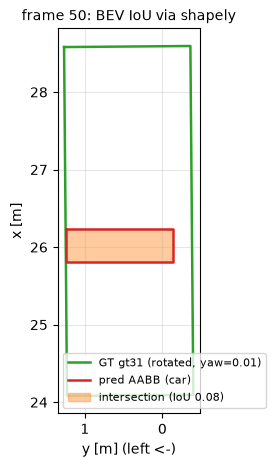

In [15]:
# 우리 데이터에 적용: GT 회전 박스(조각 2 모서리) vs 예측 AABB(yaw = 0) 의 BEV IoU
def bev_iou_shapely(corners_a, corners_b):
    """(4,2) 모서리 두 개 → IoU = 교집합 / (A + B − 교집합). 꼭짓점 순서(시계/반시계) 는 무관."""
    pa, pb = Polygon(corners_a), Polygon(corners_b)
    inter = pa.intersection(pb).area
    union = pa.area + pb.area - inter
    return inter / union if union > 0 else 0.0

def aabb_corners_bev(center, size):
    """예측 박스: yaw = 0 인 AABB. size = [l, w, h] 의 l 은 x, w 는 y 방향. 순서 = 조각 2 와 같은 앞좌, 앞우, 뒤우, 뒤좌."""
    cx, cy, l, w = center[0], center[1], size[0], size[1]
    return np.array([[cx + l / 2, cy + w / 2], [cx + l / 2, cy - w / 2], [cx - l / 2, cy - w / 2], [cx - l / 2, cy + w / 2]])

# (1) 프레임 50 매칭 쌍 (조각 3) 의 IoU
ious50 = [(preds50[i].class_name, gts50[j]["tracklet_id"], bev_iou_shapely(aabb_corners_bev(preds50[i].center, preds50[i].size), gts50[j]["corners"][:2, :4].T)) for i, j, _ in m_h]
print("frame 50 매칭 쌍 IoU:", [(c, g, round(v, 3)) for c, g, v in ious50])
print("  예측 크기 [l, w, h] =", [np.round(preds50[i].size, 2).tolist() for i, _, _ in m_h], "vs GT [l, w, h] =", [np.round(gts50[j]["size"], 2).tolist() for _, j, _ in m_h], "→ 클러스터 AABB 는 보이는 면만 담아 GT 의 1/4 넓이")

# (2) 무작위 회전 박스 300 쌍 (검증 셀에서 정답지와 비교)
def random_box():
    c = rng.uniform(-5, 5, size=2); s = rng.uniform(1, 5, size=2); yaw = rng.uniform(-np.pi, np.pi)
    R = np.array([[np.cos(yaw), -np.sin(yaw)], [np.sin(yaw), np.cos(yaw)]])
    local = np.array([[s[0] / 2, s[1] / 2], [s[0] / 2, -s[1] / 2], [-s[0] / 2, -s[1] / 2], [-s[0] / 2, s[1] / 2]])
    return c, s, yaw, local @ R.T + c
rand_pairs = [(random_box(), random_box()) for _ in range(300)]
ious_rand = np.array([bev_iou_shapely(a[3], b[3]) for a, b in rand_pairs])
print(f"무작위 300 쌍: IoU 범위 [{ious_rand.min():.3f}, {ious_rand.max():.3f}], 0 인 쌍 {(ious_rand == 0).sum()}개")

# 그림: 프레임 50 의 첫 매칭 쌍
i, j, _ = m_h[0]
ca, cb = aabb_corners_bev(preds50[i].center, preds50[i].size), gts50[j]["corners"][:2, :4].T
inter = Polygon(ca).intersection(Polygon(cb))
fig, ax = plt.subplots(figsize=(5, 5))
for c, col, lab in [(cb, "tab:green", f"GT gt{gts50[j]['tracklet_id']} (rotated, yaw={gts50[j]['rz']:.2f})"), (ca, "tab:red", f"pred AABB ({preds50[i].class_name})")]:
    cc = np.vstack([c, c[:1]]); ax.plot(cc[:, 1], cc[:, 0], color=col, lw=1.8, label=lab)
if inter.area > 0:
    xy = np.array(inter.exterior.coords); ax.fill(xy[:, 1], xy[:, 0], color="tab:orange", alpha=0.4, label=f"intersection (IoU {ious50[0][2]:.2f})")
ax.invert_xaxis(); ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=8); ax.set_xlabel("y [m] (left <-)"); ax.set_ylabel("x [m]"); ax.set_title("frame 50: BEV IoU via shapely", fontsize=10); plt.show()

In [16]:
# 검증: 정답지 bev_iou (Sutherland–Hodgman 직접 구현) 와 allclose — 무작위 300 쌍 + 프레임 50 매칭 쌍
from perceptrack3d.evaluation.metrics import bev_iou

ref_rand = np.array([bev_iou((a[0], a[1], a[2]), (b[0], b[1], b[2])) for a, b in rand_pairs])
ref50 = [bev_iou((preds50[i].center, preds50[i].size, 0.0), (gts50[j]["center"], gts50[j]["size"], gts50[j]["rz"])) for i, j, _ in m_h]
print(f"무작위 300 쌍 최대 차이 {np.abs(ref_rand - ious_rand).max():.2e}, 프레임 50 쌍 최대 차이 {max(abs(r - v) for r, (_, _, v) in zip(ref50, ious50)):.2e}")
assert np.allclose(ref_rand, ious_rand, atol=1e-9) and np.allclose(ref50, [v for *_, v in ious50], atol=1e-9)
print("→ 같다. 정답지가 shapely 를 안 쓴 이유 한 줄: 의존성 0 으로 재현성을 지키고, 사각형은 볼록이라 클리핑 40줄이면 정확하며 알고리즘이 코드로 드러난다 (학습 목적)")

무작위 300 쌍 최대 차이 1.05e-15, 프레임 50 쌍 최대 차이 5.81e-15
→ 같다. 정답지가 shapely 를 안 쓴 이유 한 줄: 의존성 0 으로 재현성을 지키고, 사각형은 볼록이라 클리핑 40줄이면 정확하며 알고리즘이 코드로 드러난다 (학습 목적)


### 이어붙이기 — `evaluate(preds_by_frame, gts_by_frame, tau)` 로 변형 A / B / C 표 재현

조각 2(GT) + 3(매칭) + 4(지표) + 5(IoU) 를 40줄 접착 코드로 묶는다. 결과를 `outputs/phase8/results.md` 의 τ = 2 m 표(재현율·정밀도·F1·MOTA·BEV median·깊이 bias·IoU mean·IDSW, 거리 구간별 재현율) 와 ±0.01 안에서, 정답지 `evaluate_variant` 와는 수치 그대로 비교한다.

변형 정의: A = `objects_raw.json` 의 `status == "ok"` (크기 없음 → IoU n/a), B = `objects_clustered.json` 의 `status == "ok"` (AABB 크기), C = `tracks.json` 의 `confirmed` 트랙 (coasting 포함, 마지막 관측 크기).
거리 구간은 **GT 의 BEV 거리** √(x² + y²) 기준 0–20 / 20–40 / 40–70 m.

In [17]:
def range_bin(center):
    r = float(np.hypot(center[0], center[1]))
    return "0-20" if r < 20 else "20-40" if r < 40 else "40-70" if r <= 70 else None

def preds_from_objects(objs_by_frame):
    return {f: [{"center": np.asarray(o.center, float), "size": None if o.size is None else np.asarray(o.size, float), "track_id": None}
                for o in objs if o.status == "ok" and o.center is not None] for f, objs in objs_by_frame.items()}

def preds_from_tracks(tr_by_frame):
    return {f: [{"center": np.asarray(r["center"], float), "size": None if r["size"] is None else np.asarray(r["size"], float), "track_id": int(r["track_id"])}
                for r in rows if r["confirmed"] and r["center"] is not None] for f, rows in tr_by_frame.items()}

def evaluate(preds_by_frame, gts_by_frame, tau):
    """프레임별 BEV 중심 거리 헝가리안 매칭 → TP/FP/FN, 재현율·정밀도·F1·MOTA, 오차 통계, IoU(크기 있는 쌍), IDSW(track_id 있는 경우), 거리 구간별 재현율."""
    frames = sorted(set(preds_by_frame) | set(gts_by_frame))
    n_pred = n_gt = tp = 0; bev, depth, ious, assignments = [], [], [], []
    bin_gt, bin_tp = collections.Counter(), collections.Counter()
    for f in frames:
        preds = preds_by_frame.get(f, []); gts = select_gt(gts_by_frame.get(f, []))          # 조각 3: GT 필터
        Pm = np.array([p["center"] for p in preds]).reshape(-1, 3); Gm = np.array([g["center"] for g in gts]).reshape(-1, 3)
        matches = match_hungarian(Pm, Gm, tau)                                                # 조각 3: 매칭
        n_pred += len(Pm); n_gt += len(Gm); tp += len(matches)
        for g in gts: bin_gt[range_bin(g["center"])] += 1
        frame_assign = []
        for i, j, d in matches:
            p, g = preds[i], gts[j]
            bev.append(d); depth.append(p["center"][0] - g["center"][0]); bin_tp[range_bin(g["center"])] += 1
            if p["size"] is not None:
                ious.append(bev_iou_shapely(aabb_corners_bev(p["center"], p["size"]), g["corners"][:2, :4].T))   # 조각 5
            if p["track_id"] is not None:
                frame_assign.append((p["track_id"], g["tracklet_id"]))
        assignments.append(frame_assign)
    has_tracks = any(len(a) for a in assignments)
    idsw = count_idsw(assignments) if has_tracks else 0                                           # 조각 4
    out = {"n_gt": n_gt, "n_pred": n_pred, "tp": tp, "fp": n_pred - tp, "fn": n_gt - tp, **precision_recall_f1(tp, n_pred, n_gt),
           "mota": mota_score(n_gt - tp, n_pred - tp, idsw, n_gt), "bev_mean": float(np.mean(bev)), "bev_median": float(np.median(bev)),
           "depth_bias": float(np.mean(depth)), "iou_mean": float(np.mean(ious)) if ious else float("nan"), "idsw": idsw if has_tracks else None,
           "recall_by_range": {k: bin_tp[k] / bin_gt[k] if bin_gt[k] else float("nan") for k in ("0-20", "20-40", "40-70")}}
    return out

variants = {"A raw": preds_from_objects(objects_A), "B clustered": preds_from_objects(objects_B), "C tracked": preds_from_tracks(tracks_C)}
results = {name: evaluate(p, GT, TAU) for name, p in variants.items()}

# outputs/phase8/results.md §1.1 / §2 의 τ = 2 m 값 (소수 2자리)
expected = {"A raw":       {"recall": 0.45, "precision": 0.53, "f1": 0.48, "mota": 0.05, "bev_median": 1.48, "depth_bias": -1.29, "iou_mean": None, "idsw": None, "0-20": 0.76, "20-40": 0.35, "40-70": 0.49},
            "B clustered": {"recall": 0.66, "precision": 0.84, "f1": 0.74, "mota": 0.53, "bev_median": 0.56, "depth_bias": -0.30, "iou_mean": 0.23, "idsw": None, "0-20": 0.81, "20-40": 0.86, "40-70": 0.50},
            "C tracked":   {"recall": 0.65, "precision": 0.78, "f1": 0.71, "mota": 0.46, "bev_median": 0.56, "depth_bias": -0.33, "iou_mean": 0.24, "idsw": 9,    "0-20": 0.80, "20-40": 0.87, "40-70": 0.46}}
rows = []
n_bad = 0
for name, r in results.items():
    e = expected[name]
    row = {"variant": name, "GT": r["n_gt"], "pred": r["n_pred"], "TP": r["tp"], "recall": r["recall"], "precision": r["precision"], "F1": r["f1"], "MOTA": r["mota"],
           "BEV median": r["bev_median"], "depth bias": r["depth_bias"], "IoU mean": r["iou_mean"], "IDSW": r["idsw"], **{f"R {k}": v for k, v in r["recall_by_range"].items()}}
    rows.append(row)
    for k_mine, k_exp in [("recall", "recall"), ("precision", "precision"), ("f1", "f1"), ("mota", "mota"), ("bev_median", "bev_median"), ("depth_bias", "depth_bias"), ("iou_mean", "iou_mean")]:
        if e[k_exp] is not None and abs(r[k_mine] - e[k_exp]) > 0.01: n_bad += 1; print("  차이:", name, k_mine, r[k_mine], e[k_exp])
    for k in ("0-20", "20-40", "40-70"):
        if abs(r["recall_by_range"][k] - e[k]) > 0.01: n_bad += 1; print("  차이:", name, k, r["recall_by_range"][k], e[k])
    if e["idsw"] is not None and r["idsw"] != e["idsw"]: n_bad += 1; print("  차이:", name, "idsw", r["idsw"], e["idsw"])
table = pd.DataFrame(rows).set_index("variant").round(3)
print(f"results.md (τ = {TAU} m) 와 ±0.01 밖인 항목 수: {n_bad}"); assert n_bad == 0
table

results.md (τ = 2.0 m) 와 ±0.01 밖인 항목 수: 0


,GT,pred,TP,recall,precision,F1,MOTA,BEV median,depth bias,IoU mean,IDSW,R 0-20,R 20-40,R 40-70
variant,,,,,,,,,,,,,,
A raw,1394,1175,621,0.445,0.529,0.483,0.048,1.477,-1.288,NaN,NaN,0.760,0.353,0.491
B clustered,1394,1107,926,0.664,0.836,0.741,0.534,0.559,-0.298,0.229,NaN,0.813,0.859,0.505
C tracked,1394,1156,902,0.647,0.780,0.707,0.458,0.555,-0.334,0.241,9.0,0.800,0.874,0.464


A raw        정답지 evaluate_variant 와 동일: True   (GT 1394, 예측 1175, TP 621, IDSW None)


B clustered  정답지 evaluate_variant 와 동일: True   (GT 1394, 예측 1107, TP 926, IDSW None)


C tracked    정답지 evaluate_variant 와 동일: True   (GT 1394, 예측 1156, TP 902, IDSW 9)


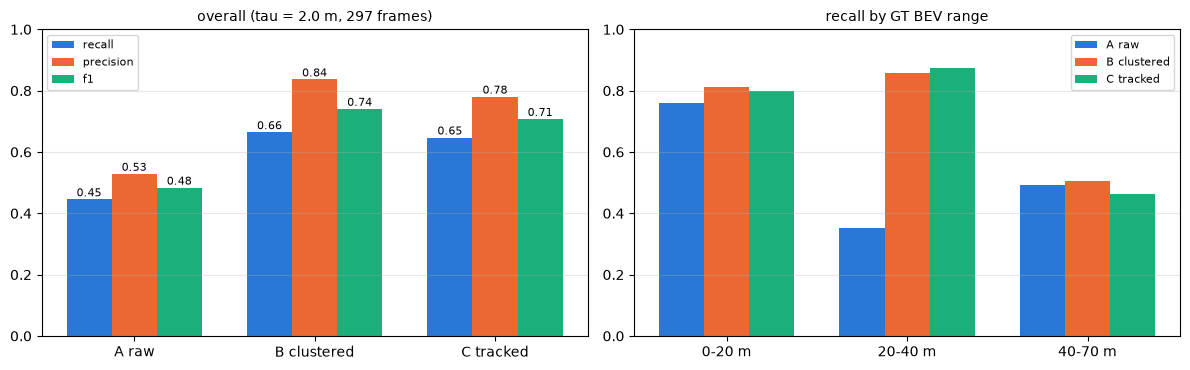

In [18]:
# 최종 비교: 정답지 evaluate_variant 와 수치 그대로 (허용 오차 1e-9)
from perceptrack3d.evaluation.evaluate import evaluate_variant

ref_inputs = {"A raw": objects_A, "B clustered": objects_B, "C tracked": tracks_C}
for name, r in results.items():
    ref = evaluate_variant(ref_inputs[name], gts_ref, cfg, name)
    o = ref["overall"]
    same = (o["n_gt"] == r["n_gt"] and o["n_pred"] == r["n_pred"] and o["n_matched"] == r["tp"]
            and np.isclose(o["recall"], r["recall"]) and np.isclose(o["precision"], r["precision"]) and np.isclose(o["mota"], r["mota"])
            and np.isclose(o["bev_median"], r["bev_median"]) and np.isclose(o["depth_bias"], r["depth_bias"])
            and (np.isnan(o["iou_mean"]) if np.isnan(r["iou_mean"]) else np.isclose(o["iou_mean"], r["iou_mean"]))
            and all(np.isclose(ref["by_range"][k]["recall"], r["recall_by_range"][k]) for k in ("0-20", "20-40", "40-70"))
            and ((ref["tracking"] or {}).get("idsw") == r["idsw"]))
    print(f"{name:<12s} 정답지 evaluate_variant 와 동일: {same}   (GT {o['n_gt']}, 예측 {o['n_pred']}, TP {o['n_matched']}, IDSW {(ref['tracking'] or {}).get('idsw')})")
    assert same

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
names = list(results); x = np.arange(len(names)); wdt = 0.25
for k, (metric, col) in enumerate([("recall", "#2a78d6"), ("precision", "#eb6834"), ("f1", "#1baf7a")]):
    vals = [results[n][metric] for n in names]
    axes[0].bar(x + (k - 1) * wdt, vals, wdt, color=col, label=metric)
    for xi, v in zip(x + (k - 1) * wdt, vals): axes[0].text(xi, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
axes[0].set_xticks(x, names); axes[0].set_ylim(0, 1); axes[0].legend(fontsize=8); axes[0].set_title(f"overall (tau = {TAU} m, 297 frames)", fontsize=10); axes[0].grid(axis="y", alpha=0.3)
bins = ["0-20", "20-40", "40-70"]
for k, (n, col) in enumerate(zip(names, ["#2a78d6", "#eb6834", "#1baf7a"])):
    vals = [results[n]["recall_by_range"][b] for b in bins]
    axes[1].bar(np.arange(3) + (k - 1) * wdt, vals, wdt, color=col, label=n)
axes[1].set_xticks(np.arange(3), [f"{b} m" for b in bins]); axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8); axes[1].set_title("recall by GT BEV range", fontsize=10); axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

읽는 법 (정답지 `results.md` §4.1–4.3 과 같은 결론): A 의 깊이 bias −1.29 m 는 "LiDAR 는 보이는 면만 찍는다" 는 물리에서 오고, 그래서 A 의 미검출 절반은 2 m 게이트 밖으로 밀린 체계적 편향이다. B 는 표면→중심 오프셋으로 bias 를 −0.30 m 로 줄여 20–40 m 구간 재현율이 0.35 → 0.86 으로 뛴다. C 는 coasting 예측(관측 없는 프레임의 칼만 예측) 때문에 정밀도가 B 보다 낮다. IoU 0.23 은 중심이 맞아도 AABB 크기가 GT 의 1/4 이라서다.

### 여기서 배우는 것

- **2012 년 파서는 Python 2 다.** `print 'x'`, `itertools.izip`, `xrange` 7줄을 고쳐야 돌아간다. 공식 배포 코드라도 "그대로 붙이면 된다" 는 보장이 없다.
- **두 공식 자료가 서로 다를 수 있다**: truncation 99 를 `tracklets.h` 는 `BEHIND_IMAGE`, `parseTrackletXML.py` 는 `TRUNC_UNSET(255)` 로 읽는다. 파서가 준 255 를 "99 였던 값" 으로 기억해야 정답지(원값 유지)와 대조된다.
- **좌표 규약은 문서가 아니라 데모 코드에 있다**: (tx, ty, tz) 가 바닥 중심이라는 것, l 이 x 방향이라는 것, rz 가 반시계 양수라는 것은 `run_demoTracklets.m` 의 모서리 세 줄에서 나온다. 그 위 주석("x -> facing right") 은 틀렸다. 점 수 검증(바닥 30591 vs 중심 23270) 으로 확인했다.
- **크기 순서**: `parseTrackletXML` 의 `size = (height, width, length)`, 정답지의 `size = [l, w, h]`. 순서 하나 틀리면 IoU 가 조용히 반토막 난다.
- **매칭 규칙이 지표를 정한다**: nuScenes 는 신뢰도 순 탐욕, 우리는 헝가리안 — 이 시퀀스에서는 거의 같지만(297 프레임 중 다른 프레임 수는 위 출력) 붐비는 장면에서는 갈린다. `<` 와 `<=`, 게이트 밖을 inf 로 두면 scipy 가 죽는다는 것까지 포함해서 "규칙을 문서에 적는다".
- **라이브러리 vs 직접 구현**: shapely 한 줄과 정답지의 클리핑 40줄은 1e-12 안에서 같다. 의존성을 넣을지는 재현성·배포 환경(ROS2, C++ 이식) 을 보고 결정한다.

### 자가 점검 3문제

1. XML 의 tz 를 그대로 `center.z` 로 쓰면 어느 지표가 어떻게 왜곡되는가? BEV 매칭(x, y 만 사용) 에는 영향이 없다면 어디에 영향이 있는가?
2. 변형 C 에서 IDSW 9 는 어떤 GT 에서 났는가(위 출력). 이 중 "칼만 필터가 잘못한" 경우와 "융합이 같은 차를 둘로 쪼갠" 경우를 구분하려면 어떤 데이터를 더 봐야 하는가?
3. τ 를 2 m 에서 4 m 로 올리면 A 의 재현율이 0.45 → 0.70 으로 뛰지만 B 는 거의 안 변한다 (results.md §1.2). `evaluate(..., tau=4.0)` 으로 확인하고, 이 차이가 말해 주는 A 오차의 성질을 한 문장으로 쓰라.

<details>
<summary>답</summary>

1. GT 중심이 h/2 (승용차 ~0.75 m) 만큼 낮아져 3D 중심 오차 `‖p − g‖` 와 3D IoU 가 나빠진다. BEV 거리·BEV IoU·재현율·정밀도는 (x, y) 만 쓰므로 그대로다.
2. gt3, gt7, gt11, gt32, gt25 (07 노트북 꼬리에서 gt3 을 재현). 구분하려면 그 프레임의 융합 객체 `status`/`n_points` (깜빡임 → 트랙 사망·재생성) 와 같은 프레임에 GT 2 m 안에 `ok` 객체가 2개인지 (클러스터 분열 → 트랙 2개가 번갈아 붙음) 를 본다. 둘 다 위치 추정·할당의 문제가 아니라 관측 결손·중복이다.
3. A 의 오차는 무작위가 아니라 **한쪽으로 치우친 편향** (표면 중앙값이 GT 중심보다 항상 ~1.3–1.8 m 가깝다) 이라, 게이트를 넓히면 "미검출" 이 대거 TP 로 바뀐다. B 는 편향을 이미 보정했으므로 게이트를 넓혀도 새로 들어오는 쌍이 적다.

</details>